# ML2 Assignment #3, Task 1: Regularization, feature deselection, and LASSO abilities

**Janin Jankovski, Florian Robrecht, Anna Hartmann**

---

**Dataset:** Synthetic phyisical activity dataset

**Pipeline**

1: Data generation <br>
2: Exploratory Data Analysis (EDA)<br>
3: Regularization model and evaluation<br>
4: ElasticNet Experiment<br>
5: Take-home message

In [22]:
# load libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook")
cmap = plt.cm.coolwarm
colors = cmap(np.linspace(0, 1, len(df.columns)))

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score, mean_squared_error

np.random.seed(42)

## 1. Data generation

We construct a synthetic dataset representing physical activity and energy expenditure. One row represents one workout session (generic step-based cardio workout).

The target variable is calories burned. The dataset includes:
- strong predictors (duration, heart rate, steps, weight)
- correlated features (active minutes, distance, height)
- weak predictors (gender, sleep)
- irrelevant noise features

In [12]:
n = 800 # 800 workouts

# Gender (0 = female, 1 = male)
gender = np.random.binomial(1, 0.5, n) # 50% female, 50% male

# Height depends on gender
height = np.where(gender == 1,
                  np.random.normal(178, 7, n), # men are taller on average
                  np.random.normal(165, 6, n))

# Weight correlated with height and gender (indirectly)
weight = 0.45 * height + np.random.normal(0, 8, n)

# Activity features
duration = np.random.normal(45, 12, n) # 45 minutes average workout duration
heart_rate = np.random.normal(135, 18, n) # 135 average heart rate during workout
steps = duration * 110 + np.random.normal(0, 800, n) # steps correlate with duration but have some noise

# Correlated features (redundancy, multicollinearity)
active_minutes = duration + np.random.normal(0, 4, n)
distance = steps / 1300 + np.random.normal(0, 0.4, n)

# Weak lifestyle features
sleep = np.random.normal(7, 2, n) # 7 hours average sleep
water = np.random.normal(2.2, 0.6, n)

# Pure noise features
noise = np.random.normal(size=(n, 6)) # completely random features from standard normal distribution

# Target (calories)
calories = (
    4.5 * duration
    + 1.8 * heart_rate
    + 0.035 * steps
    + 2.5 * weight
    + 40 * gender   # men burn more on average (+ 40 calories)
    + 5 * sleep     # small effect
    + np.random.normal(0, 80, n)
)

columns = [
    "duration", "heart_rate", "steps",
    "weight", "height", "gender",
    "active_minutes", "distance",
    "sleep", "water"
] + [f"noise_{i}" for i in range(1, 7)]

X = np.column_stack([
    duration, heart_rate, steps,
    weight, height, gender,
    active_minutes, distance,
    sleep, water,
    noise
])

df = pd.DataFrame(X, columns=columns)
df["calories"] = calories

display(df.head())
display(df.shape)

,duration,heart_rate,steps,weight,height,gender,active_minutes,distance,sleep,water,noise_1,noise_2,noise_3,noise_4,noise_5,noise_6,calories
0,59.403141,127.801817,6171.436400,72.836678,168.229776,0.0,59.538752,5.226979,11.097417,2.559398,-0.790017,0.692815,-0.283707,1.190475,1.021963,0.211209,877.993874
1,39.442064,139.847306,5719.608239,76.404791,181.300278,1.0,34.680433,4.386788,3.749015,2.712009,-0.339530,0.960932,0.646905,-0.684440,-1.327799,-0.288533,899.911379
2,40.062881,134.191925,3697.053312,91.981913,191.174171,1.0,43.766781,2.809053,5.886442,1.903486,1.515414,1.146487,-1.112327,-1.167757,1.274684,-1.135636,800.705070
3,58.846809,138.285019,7090.585911,82.888280,187.417940,1.0,58.482505,6.206247,7.065278,2.370307,0.509295,-0.616071,1.617045,-0.770425,1.143362,0.184859,1022.284540
4,22.563100,122.937926,2766.943187,66.234031,158.731145,0.0,21.852716,2.336720,9.274762,2.777502,0.252195,-1.970309,-2.202913,-0.220566,0.246906,-1.125198,713.606019


(800, 17)

## 2: Exploratory Data Analysis (EDA)

We construct a synthetic dataset representing physical activity and energy expenditure. One row represents one workout session (generic step-based cardio workout).

The target variable is calories burned. The dataset includes:

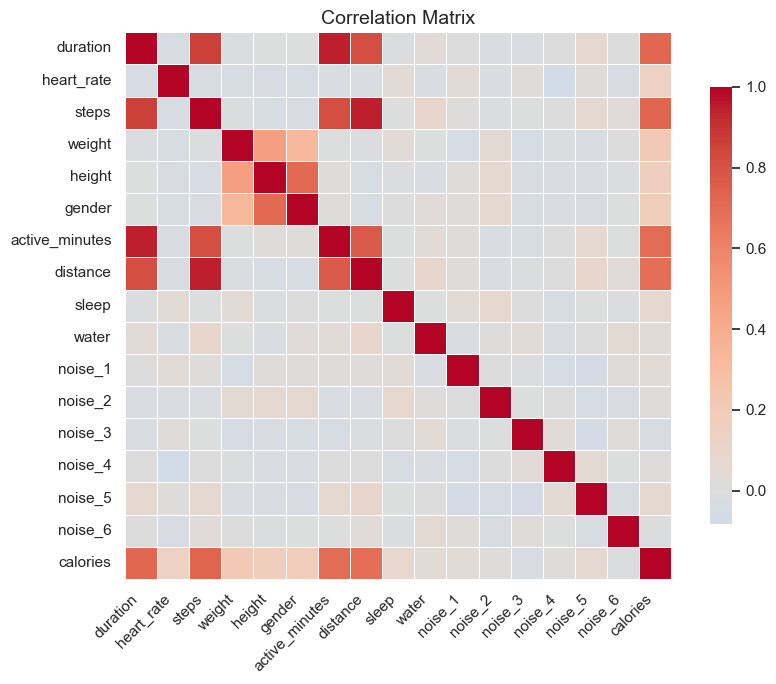

In [29]:
# Heatmap of feature correlations
plt.figure(figsize=(9, 7))

corr = df.corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=False,        # with numbers
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

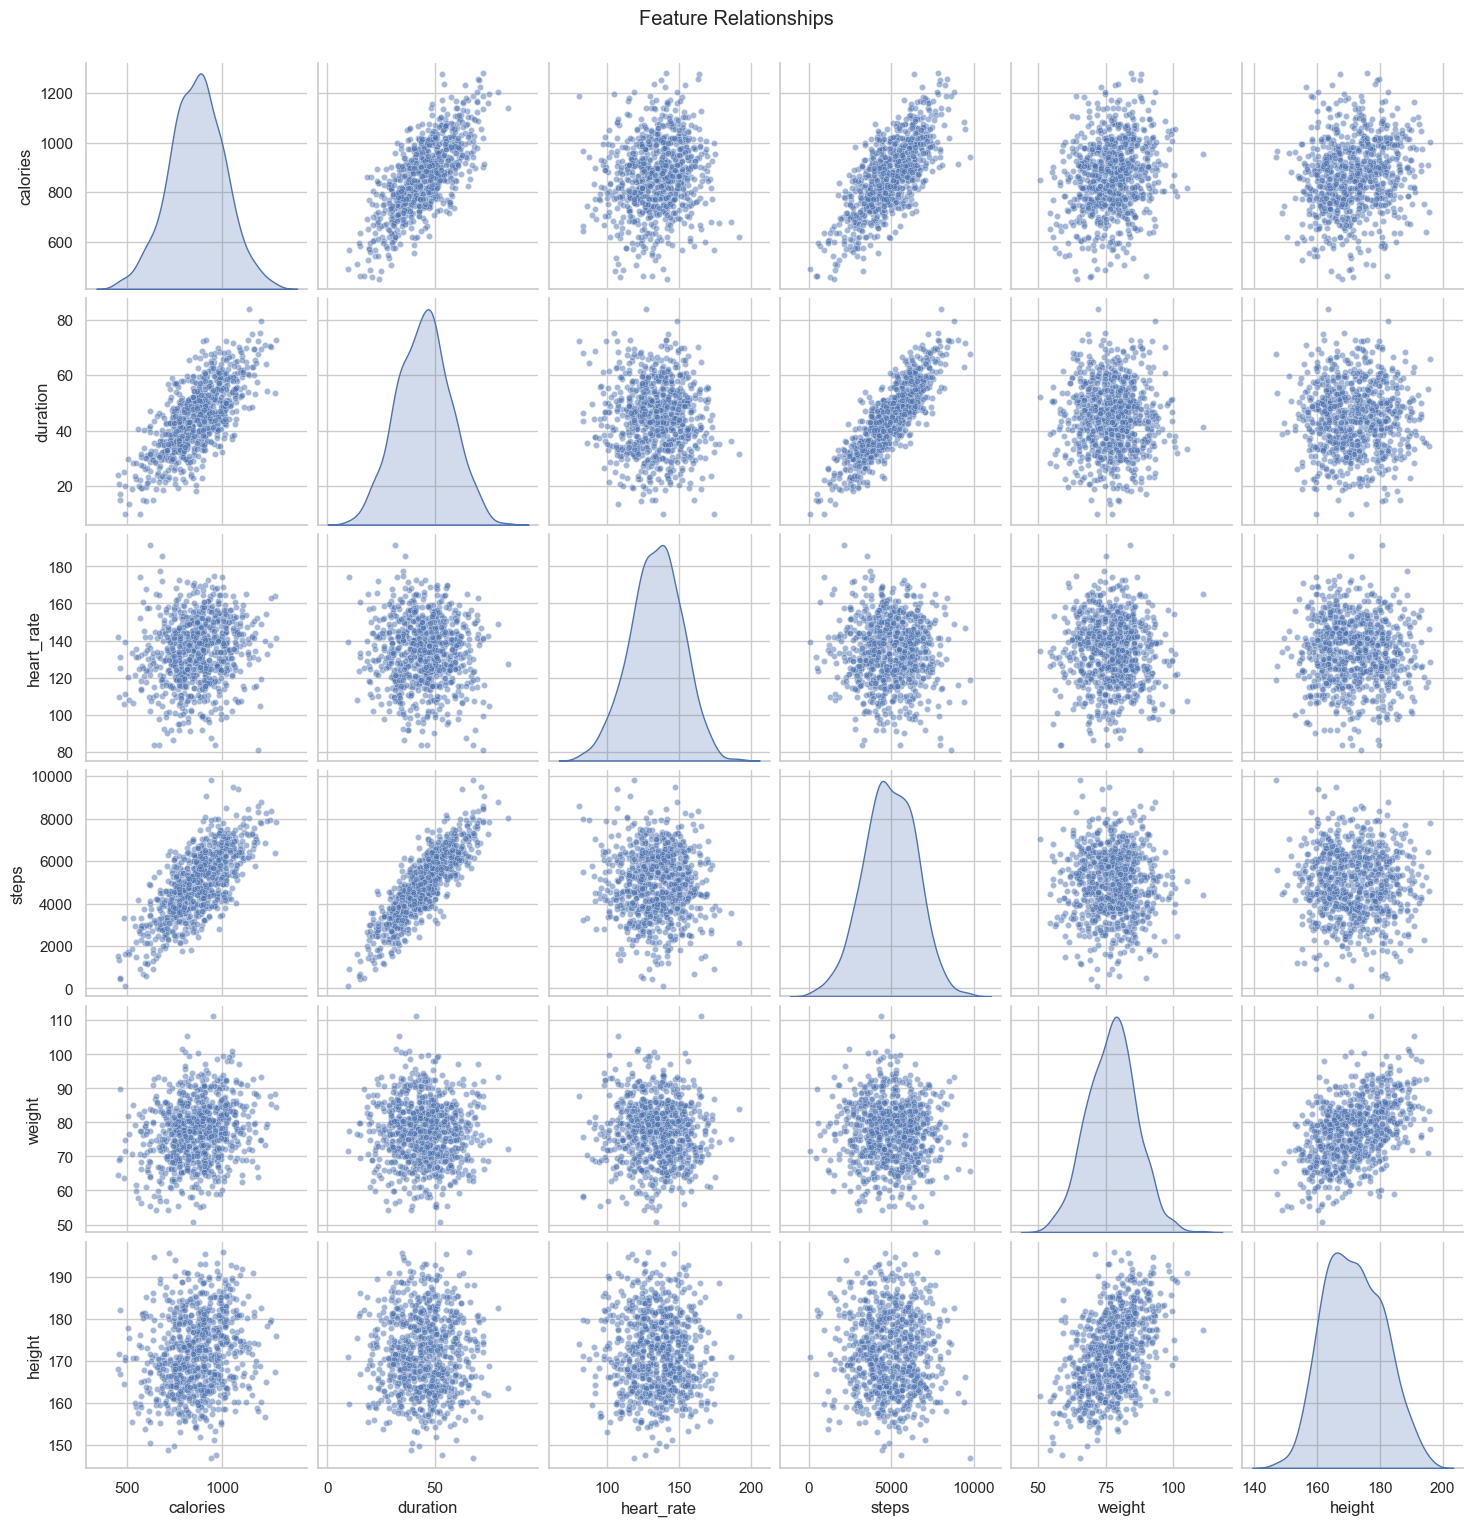

In [30]:
# Pairplot
subset_cols = ["calories", "duration", "heart_rate", "steps", "weight", "height"]

sns.pairplot(
    df[subset_cols],
    diag_kind="kde",
    plot_kws={"alpha": 0.5, "s": 20},
    diag_kws={"fill": True}
)

plt.suptitle("Feature Relationships", y=1.02)
plt.show()

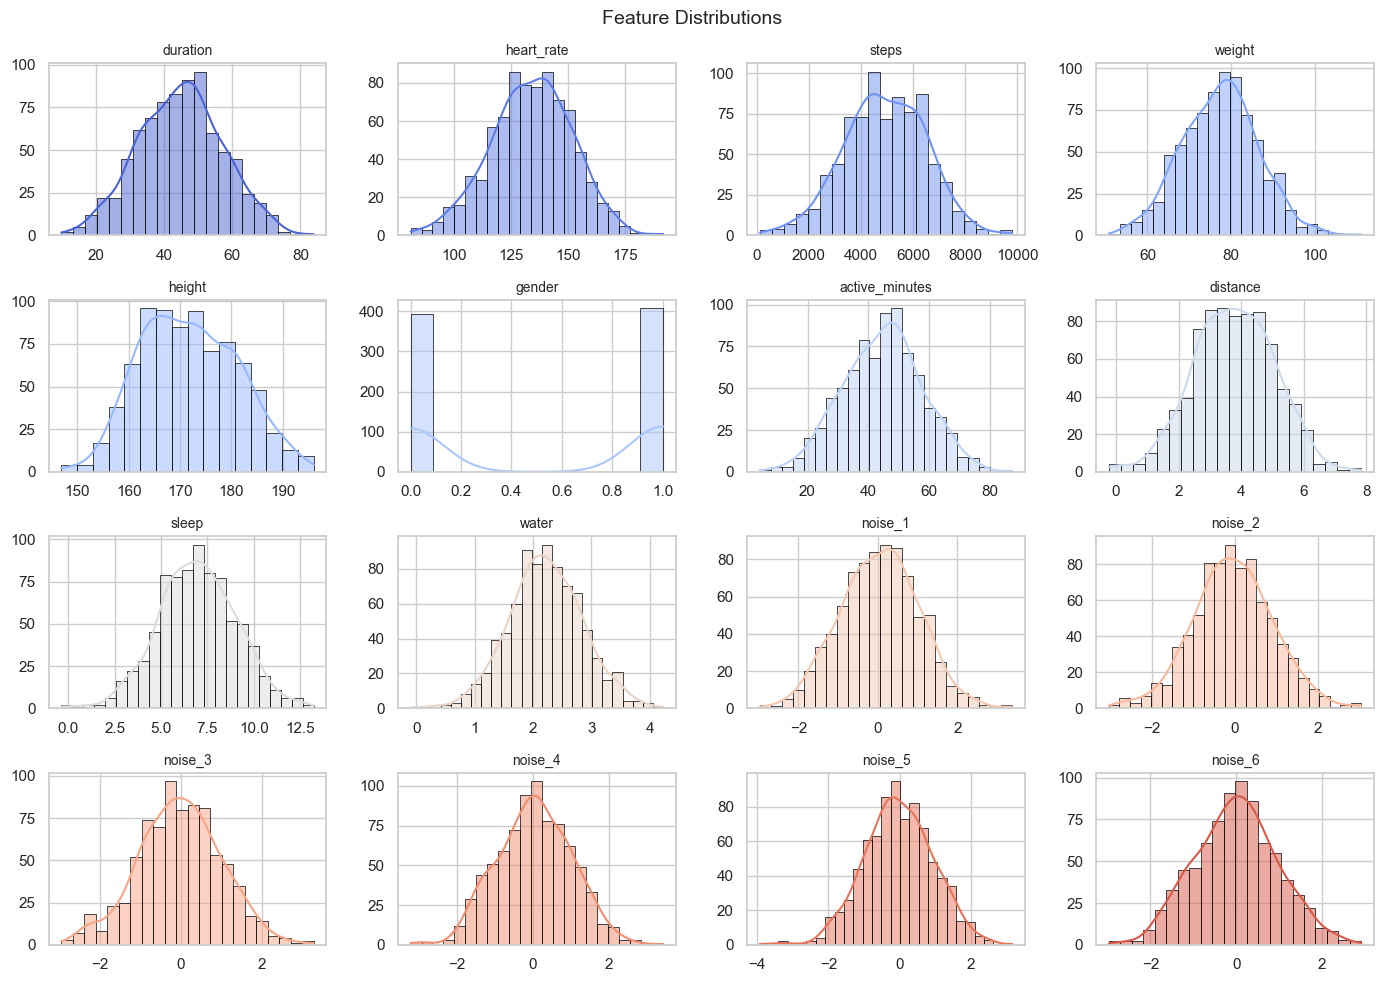

In [21]:
# histograms
fig, axes = plt.subplots(4, 4, figsize=(14, 10))
axes = axes.flatten()

colors = sns.color_palette("coolwarm", len(df.columns))

for i, (ax, col) in enumerate(zip(axes, df.columns)):
    sns.histplot(
        df[col],
        kde=True,
        ax=ax,
        color=colors[i],
        edgecolor="black",
        linewidth=0.5
    )
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("")

# Remove empty plots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Feature Distributions", fontsize=14)
plt.tight_layout()
plt.show()

## 3. Regularization framework

We evaluate:
- Prediction performance: how well the model predicts unseen data (R² and RMSE)
- Feature selection: how many features are used by the model
- Model stability: how smoothly coefficients change as regularization increases (analyzed using coefficient paths)

In [31]:
# target: calories burned
X = df.drop(columns="calories")
y = df["calories"]

# train test split (70% - 30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# scale
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

feature_names = X.columns

### Regularization methods

Ridge, LASSO, and ElasticNet all extend ordinary linear regression by adding a penalty term to the loss function.

**Ridge regression**

Ridge minimizes:

$$
\min_w \frac{1}{2n} \lVert y - Xw \rVert_2^2 + \alpha \lVert w \rVert_2^2
$$

The L2 penalty shrinks coefficients toward zero, but usually does not set them exactly to zero. Therefore, Ridge is useful for stabilizing models with correlated features, but it does not perform true feature selection.

**LASSO regression**

LASSO minimizes:

$$
\min_w \frac{1}{2n} \lVert y - Xw \rVert_2^2 + \alpha \lVert w \rVert_1
$$

The L1 penalty can set coefficients exactly to zero. This makes LASSO useful for feature selection and feature deselection.

**ElasticNet regression**

ElasticNet combines both penalties:

$$
\min_w \frac{1}{2n} \lVert y - Xw \rVert_2^2
+ \alpha \left(
l1\_ratio \lVert w \rVert_1
+ \frac{1-l1\_ratio}{2} \lVert w \rVert_2^2
\right)
$$

The parameter `l1_ratio` controls the mixture between LASSO and Ridge.  
A value close to 1 behaves more like LASSO, while a value close to 0 behaves more like Ridge.

In [32]:
def run_regularization_sweep(model_name, alphas, l1_ratio=None):
    results = []
    coefficients = []

    for alpha in alphas:
        if model_name == "Ridge":
            model = Ridge(alpha=alpha)
        elif model_name == "LASSO":
            model = Lasso(alpha=alpha, max_iter=10000)
        elif model_name == "ElasticNet":
            model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=10000)
        else:
            raise ValueError("model_name must be Ridge, LASSO, or ElasticNet")

        model.fit(X_train_scaled, y_train)

        train_pred = model.predict(X_train_scaled)
        test_pred = model.predict(X_test_scaled)

        train_r2 = r2_score(y_train, train_pred)
        test_r2 = r2_score(y_test, test_pred)
        test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

        active_features = np.sum(np.abs(model.coef_) > 1e-6)

        results.append({
            "model": model_name,
            "alpha": alpha,
            "l1_ratio": l1_ratio,
            "train_r2": train_r2,
            "test_r2": test_r2,
            "test_rmse": test_rmse,
            "active_features": active_features
        })

        coefficients.append(model.coef_)

    results_df = pd.DataFrame(results)
    coef_df = pd.DataFrame(coefficients, columns=feature_names)
    return pd.concat([results_df, coef_df], axis=1)

### Regularization sweep

The models are trained over a wide range of regularization strengths (α).
Small values of α make the model behave similarly to ordinary least squares, while large values of α enforce stronger shrinkage of the coefficients.

For ElasticNet, we use a fixed `l1_ratio = 0.5`, meaning the penalty is an equal mix of L1 and L2 regularization. This is appropriate for this dataset, as it contains both irrelevant features (noise) and groups of correlated predictors. We later analyze how different l1_ratio affect feature selection and model performance. 

In [35]:
alphas = np.logspace(-3, 3, 80) # 80 values from 0.001 to 1000 on a log scale, from weak to strong regularization

ridge_results = run_regularization_sweep("Ridge", alphas)
lasso_results = run_regularization_sweep("LASSO", alphas)
elastic_results = run_regularization_sweep("ElasticNet", alphas, l1_ratio=0.5)

results = pd.concat([ridge_results, lasso_results, elastic_results], ignore_index=True)

display(results.head())
display(results.shape)

,model,alpha,l1_ratio,train_r2,test_r2,test_rmse,active_features,duration,heart_rate,steps,...,active_minutes,distance,sleep,water,noise_1,noise_2,noise_3,noise_4,noise_5,noise_6
0,Ridge,0.001000,None,0.679768,0.656333,81.093502,16,38.125624,26.775049,51.940730,...,10.183498,13.364468,9.835163,2.010961,5.886010,4.070881,-0.578563,2.375167,1.829344,-5.070570
1,Ridge,0.001191,None,0.679768,0.656332,81.093504,16,38.125541,26.775035,51.940582,...,10.183596,13.364597,9.835161,2.010961,5.886005,4.070884,-0.578561,2.375165,1.829341,-5.070567
2,Ridge,0.001419,None,0.679768,0.656332,81.093507,16,38.125441,26.775018,51.940405,...,10.183713,13.364751,9.835159,2.010961,5.885999,4.070887,-0.578559,2.375164,1.829337,-5.070564
3,Ridge,0.001690,None,0.679768,0.656332,81.093510,16,38.125323,26.774998,51.940195,...,10.183853,13.364933,9.835156,2.010961,5.885992,4.070890,-0.578556,2.375161,1.829333,-5.070561
4,Ridge,0.002013,None,0.679768,0.656332,81.093515,16,38.125182,26.774975,51.939945,...,10.184019,13.365151,9.835153,2.010961,5.885984,4.070894,-0.578553,2.375159,1.829327,-5.070557


(240, 23)

In [36]:
sns.set_theme(style="whitegrid")
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

cmap = plt.cm.coolwarm

#### 3.1. Model performance (R² and RMSE)

The figure shows training and test R² scores for different values of the regularization parameter α.

The training score measures how well the model fits the data it was trained on, while the test score shows how well the model performs on unseen data. A gap between the two indicates how well the model generalizes.

For small α, all models perform well and training and test R² are very close, indicating good generalization.

As α increases, performance decreases:

- **Ridge** shows a gradual decline in R², but maintains a noticeable gap between training and test performance.
- **LASSO** stays stable at first, but then drops sharply when too many features are removed, causing both training and test performance to decrease together.
- **ElasticNet** lies in between, with a smoother decline than LASSO.

The RMSE follows the same pattern: it is low when R² is high and increases as regularization becomes stronger.

Overall, increasing α reduces model performance, and very large values lead to underfitting.

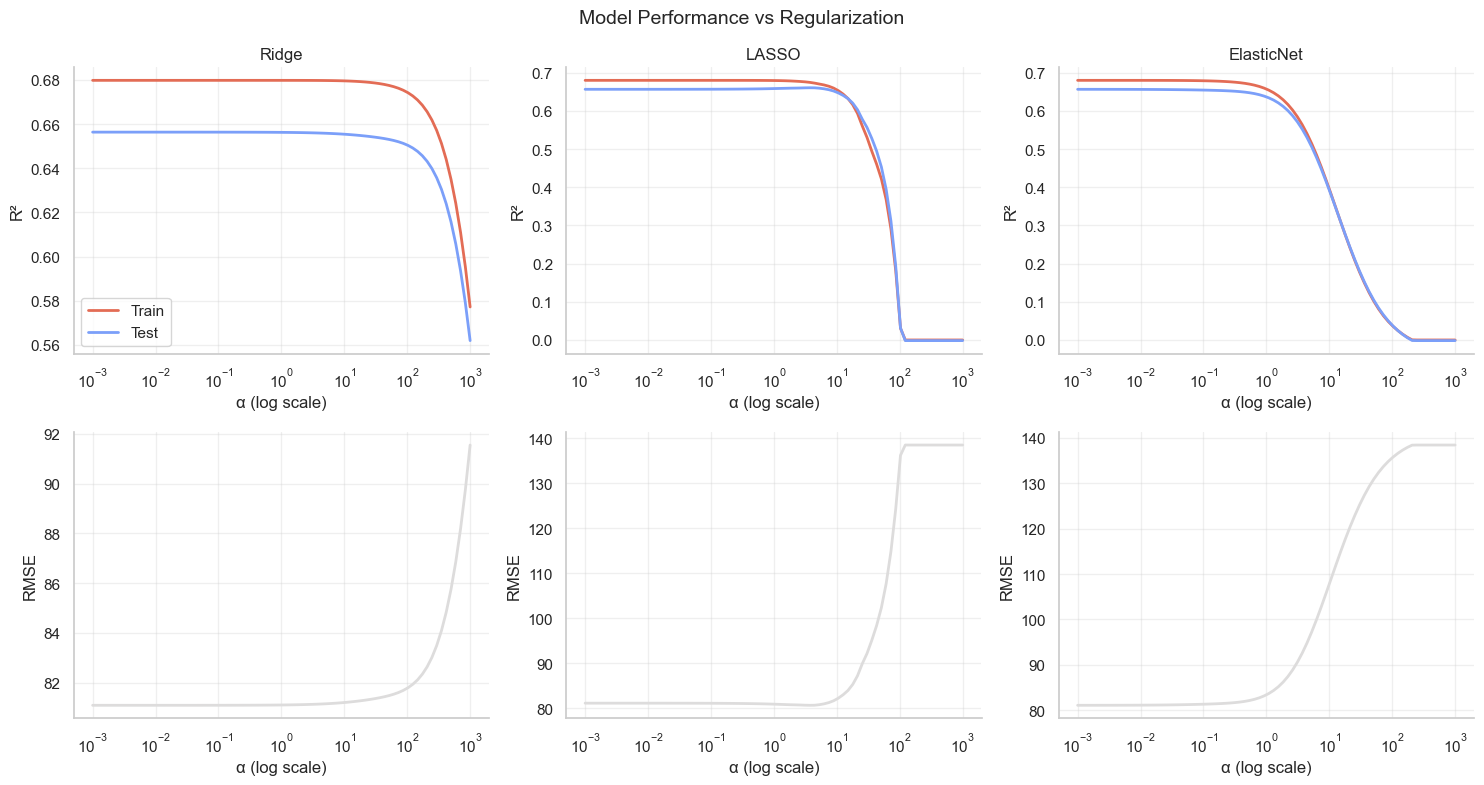

In [44]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for col_idx, (name, data) in enumerate([
    ("Ridge", ridge_results),
    ("LASSO", lasso_results),
    ("ElasticNet", elastic_results)
]):
    
    # R² (coefficient of determination)
    # Measures how well the model explains the target variable
    # 1 = perfect fit, 0 = no better than predicting the mean
    ax = axes[0, col_idx]
    ax.plot(data["alpha"], data["train_r2"], label="Train", color=cmap(0.85), linewidth=2)
    ax.plot(data["alpha"], data["test_r2"], label="Test", color=cmap(0.2), linewidth=2)

    ax.set_xscale("log")
    ax.set_title(name)
    ax.set_xlabel("α (log scale)")
    ax.set_ylabel("R²")
    ax.grid(alpha=0.3)

    if col_idx == 0:
        ax.legend()

    # RMSE (Root Mean Squared Error)
    # Measures average prediction error (lower = better)
    ax = axes[1, col_idx]
    ax.plot(data["alpha"], data["test_rmse"], color=cmap(0.5), linewidth=2)

    ax.set_xscale("log")
    ax.set_xlabel("α (log scale)")
    ax.set_ylabel("RMSE")
    ax.grid(alpha=0.3)

plt.suptitle("Model Performance vs Regularization", fontsize=14)
plt.tight_layout()
plt.show()

#### 3.2. Feature selection

The figure shows the number of active features as the regularization parameter α increases.

- **Ridge** keeps all features regardless of α, as it only shrinks coefficients but does not remove them.

- **LASSO** reduces the number of active features as α increases. Features are removed step by step, and for large α only a few or no features remain.

- **ElasticNet** shows similar behavior to LASSO, but the decrease is smoother. It removes features gradually while still keeping some correlated variables longer.

Overall, LASSO and ElasticNet perform feature selection, while Ridge does not.

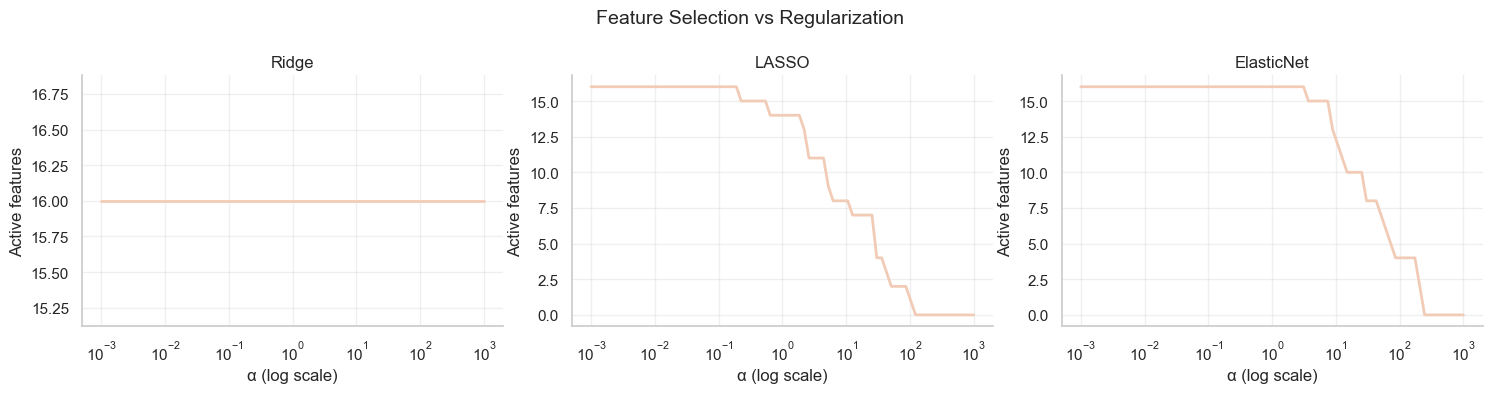

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, data) in zip(axes, [
    ("Ridge", ridge_results),
    ("LASSO", lasso_results),
    ("ElasticNet", elastic_results)
]):
    ax.plot(data["alpha"], data["active_features"], color=cmap(0.6), linewidth=2)

    ax.set_xscale("log")
    ax.set_title(name)
    ax.set_xlabel("α (log scale)")
    ax.set_ylabel("Active features")

    ax.grid(alpha=0.3)

plt.suptitle("Feature Selection vs Regularization", fontsize=14)
plt.tight_layout()
plt.show()

#### 3.3. Coefficient paths

The figure shows how the model coefficients change as the regularization parameter α increases.

For small values of α, all models assign the largest coefficients to the strong predictors (duration, heart rate, steps, weight), reflecting their importance for predicting calories.

- **Ridge** shows smooth and continuous shrinkage of all coefficients towards zero. Strong predictors remain dominant, while weaker and noise features are gradually reduced but never fully removed. Correlated features (active minutes, distance, height) tend to move together, sharing the effect.

- **LASSO** shows abrupt changes, where coefficients are set exactly to zero. Noise features are removed first, followed by weaker predictors. Among correlated features, LASSO tends to select one and drop the others, leading to sudden changes in the paths.

- **ElasticNet** lies in between. It shrinks coefficients smoothly like Ridge but can also set some to zero. Correlated features are reduced together rather than being eliminated abruptly, while noise features are still removed.

Overall, the coefficient paths show that the models correctly identify strong predictors, remove irrelevant noise, and handle correlated features differently: Ridge distributes weights, LASSO selects one, and ElasticNet provides a balance between both.

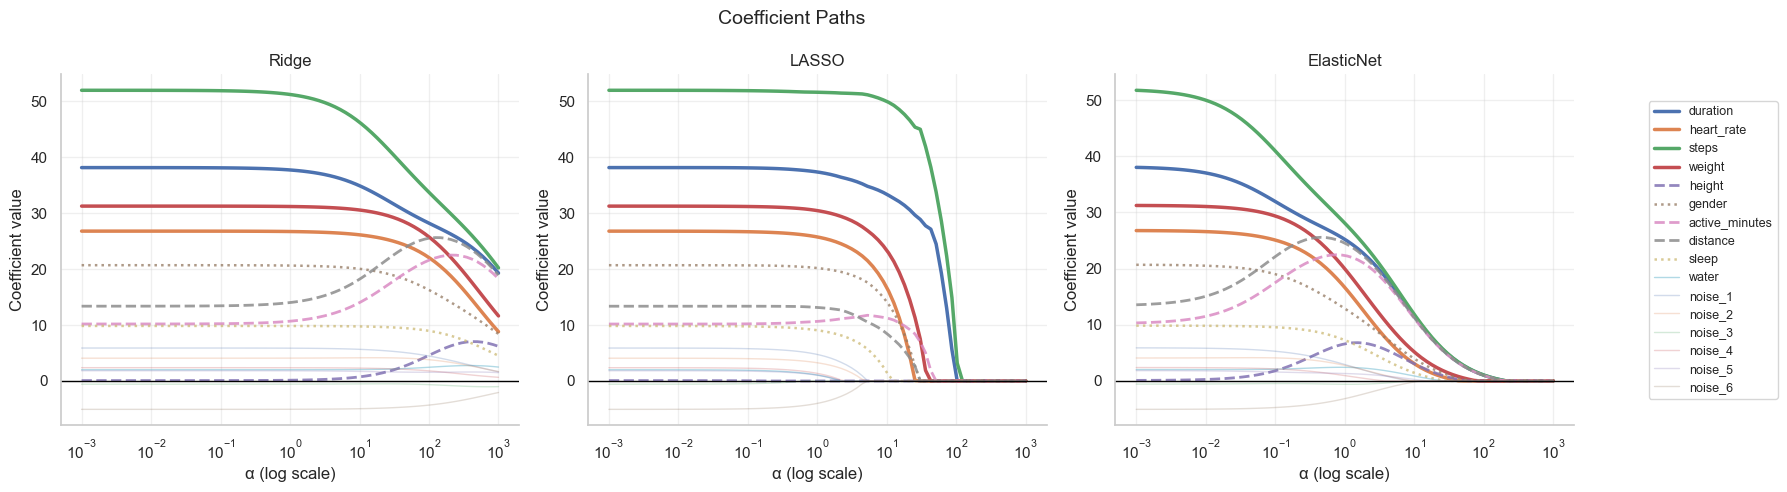

In [ ]:
strong_features = ["duration", "heart_rate", "steps", "weight"]
correlated_features = ["active_minutes", "distance", "height"]
weak_features = ["gender", "sleep"]
noise_features = [col for col in feature_names if col.startswith("noise")]

feature_styles = {}

for col in strong_features:
    feature_styles[col] = {"linewidth": 2.5, "alpha": 1.0, "linestyle": "-"}
for col in correlated_features:
    feature_styles[col] = {"linewidth": 2.0, "alpha": 0.85, "linestyle": "--"}
for col in weak_features:
    feature_styles[col] = {"linewidth": 1.8, "alpha": 0.75, "linestyle": ":"}
for col in noise_features:
    feature_styles[col] = {"linewidth": 1.0, "alpha": 0.25, "linestyle": "-"}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, data) in zip(axes, [
    ("Ridge", ridge_results),
    ("LASSO", lasso_results),
    ("ElasticNet", elastic_results)
]):
    for col in feature_names:
        style = feature_styles.get(col, {"linewidth": 1, "alpha": 0.5, "linestyle": "-"})
        ax.plot(
            data["alpha"],
            data[col],
            label=col,
            linewidth=style["linewidth"],
            alpha=style["alpha"],
            linestyle=style["linestyle"]
        )

    ax.set_xscale("log")
    ax.axhline(0, color="black", linewidth=1)

    ax.set_title(name)
    ax.set_xlabel("α (log scale)")
    ax.set_ylabel("Coefficient value")
    ax.grid(alpha=0.3)

# legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="center right",
    bbox_to_anchor=(1.12, 0.5),
    fontsize=9
)

plt.suptitle("Coefficient Paths", fontsize=14)
plt.tight_layout()
plt.show()

Note: Correlated features such as duration and active minutes or steps and distance can temporarily increase because the model shifts weight between similar variables.
This effect is stronger in Ridge, which spreads weights across features, while LASSO tends to select one and set the others to zero.

## 4. ElasticNet Experiment

After comparing Ridge, LASSO, and ElasticNet with a fixed `l1_ratio = 0.5`, we now test how different values of `l1_ratio` affect ElasticNet.

The `l1_ratio` controls the balance between L1 and L2 regularization:

- Low `l1_ratio` → more Ridge-like behavior
- High `l1_ratio` → more LASSO-like behavior

This allows us to study the trade-off between coefficient stability and feature selection.

In [46]:
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]

elastic_l1_results = []

for l1 in l1_ratios:
    res = run_regularization_sweep("ElasticNet", alphas, l1_ratio=l1)
    elastic_l1_results.append(res)

elastic_l1_results = pd.concat(elastic_l1_results, ignore_index=True)

elastic_l1_results.head()

,model,alpha,l1_ratio,train_r2,test_r2,test_rmse,active_features,duration,heart_rate,steps,...,active_minutes,distance,sleep,water,noise_1,noise_2,noise_3,noise_4,noise_5,noise_6
0,ElasticNet,0.001000,0.1,0.679768,0.656280,81.099725,16,37.909509,26.738487,51.559935,...,10.437760,13.695325,9.830501,2.011245,5.872655,4.077057,-0.573915,2.371024,1.821013,-5.063951
1,ElasticNet,0.001191,0.1,0.679767,0.656270,81.100913,16,37.869292,26.731534,51.488395,...,10.485205,13.757306,9.829613,2.011323,5.870126,4.078195,-0.573055,2.370239,1.819449,-5.062700
2,ElasticNet,0.001419,0.1,0.679767,0.656258,81.102317,16,37.822147,26.723280,51.403958,...,10.540949,13.830342,9.828560,2.011429,5.867131,4.079523,-0.572046,2.369308,1.817602,-5.061218
3,ElasticNet,0.001690,0.1,0.679766,0.656244,81.104002,16,37.765819,26.713463,51.303853,...,10.607381,13.916965,9.827302,2.011555,5.863566,4.081097,-0.570852,2.368196,1.815419,-5.059454
4,ElasticNet,0.002013,0.1,0.679765,0.656227,81.106004,16,37.699342,26.701809,51.185822,...,10.685769,14.019011,9.825804,2.011717,5.859336,4.082938,-0.569453,2.366872,1.812847,-5.057360


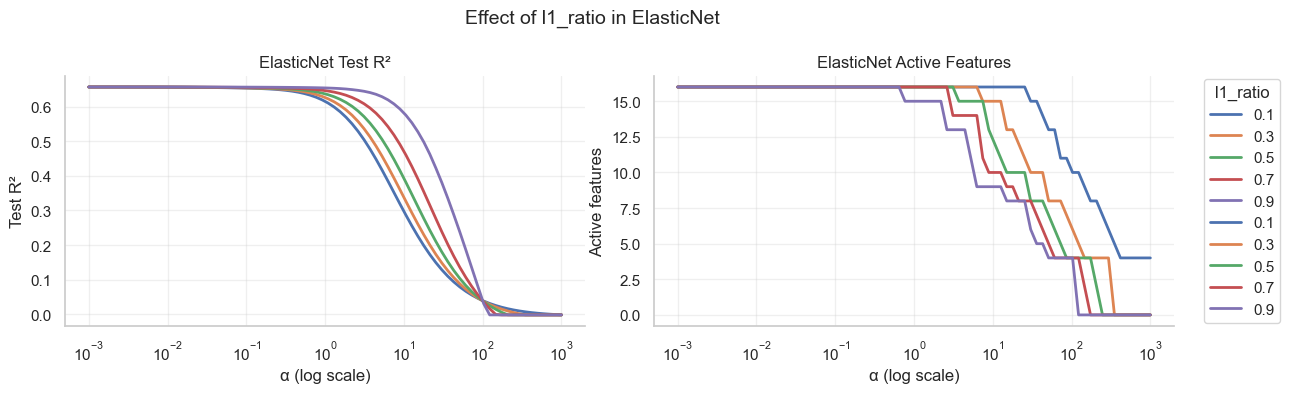

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# R²
for l1 in l1_ratios:
    data = elastic_l1_results[elastic_l1_results["l1_ratio"] == l1]
    axes[0].plot(data["alpha"], data["test_r2"], label=f"{l1}", linewidth=2)

axes[0].set_xscale("log")
axes[0].set_title("ElasticNet Test R²")
axes[0].set_xlabel("α (log scale)")
axes[0].set_ylabel("Test R²")
axes[0].grid(alpha=0.3)

# Active features
for l1 in l1_ratios:
    data = elastic_l1_results[elastic_l1_results["l1_ratio"] == l1]
    axes[1].plot(data["alpha"], data["active_features"], label=f"{l1}", linewidth=2)

axes[1].set_xscale("log")
axes[1].set_title("ElasticNet Active Features")
axes[1].set_xlabel("α (log scale)")
axes[1].set_ylabel("Active features")
axes[1].grid(alpha=0.3)

# shared legend
fig.legend(title="l1_ratio", loc="center right", bbox_to_anchor=(1.08, 0.5))

plt.suptitle("Effect of l1_ratio in ElasticNet", fontsize=14)
plt.tight_layout()
plt.show()

For small values of α, all models perform similarly (because you do not have any regularization of features). As α increases, differences become visible.

Higher values of `l1_ratio` (more LASSO-like) maintain performance slightly longer, but then drop more sharply as features are removed.

Lower values of `l1_ratio` (more Ridge-like) keep more features and show a smoother decline in performance.

Overall, increasing `l1_ratio` leads to more aggressive feature selection, while decreasing it results in more stable but less sparse models.

## 5. Take-Home Message

**Initial Question:**  
How do Ridge, LASSO, and ElasticNet perform under different levels of regularization, and how do they differ in prediction performance, feature selection, and coefficient behavior?

---

### Findings

**1. Regularization introduces a trade-off between performance and simplicity**  
For small values of α, all models achieve high performance, indicating a good fit.  
As α increases, performance decreases, showing that stronger regularization simplifies the model but can lead to underfitting.

**2. LASSO and ElasticNet perform feature selection, while Ridge does not**  
Ridge keeps all features and only shrinks coefficients.  
LASSO removes features aggressively as α increases, often eliminating noise and weaker predictors first.  
ElasticNet lies in between, gradually reducing the number of features while maintaining more stability.

**3. Models handle correlated features differently**  
Ridge distributes weights across correlated features, leading to smooth and stable coefficient paths.  
LASSO tends to select one feature from a correlated group and set the others to zero, causing abrupt changes.  
ElasticNet balances both behaviors, keeping groups of correlated features while still allowing for feature selection.